# Project: Investigate a Dataset - FBI Gun Background Checks and US Census Data

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#questions">Questions</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
<li><a href="#limitations">Limitations</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

In this project, we analyze and combine datasets to explore relationships between gun background checks and socioeconomic indicators across the United States. We use three datasets:

#### 1. FBI NICS Gun Background Check Data (`nics-data-09-2023.csv`)
This dataset contains the monthly number of firearm background checks processed by the FBI's National Instant Criminal Background Check System (NICS), categorized by state and transaction type. It serves as a proxy for gun purchase demand.
* **`month`**: The month of the transaction in `YYYY-MM` format (temporal index).
* **`state`**: The U.S. state or territory (comprising 55 unique values: the 50 states, District of Columbia, Guam, Mariana Islands, Puerto Rico, and Virgin Islands).
* **`permit` & `permit_recheck`**: Background checks conducted for concealed carry permit applications and renewals. 
* **`handgun` & `long_gun`**: Background checks for handgun and rifle/shotgun purchases.
* **`other`**: Checks for other categories of firearms (e.g., receivers, frames).
* **`multiple`**: Checks for transactions involving the purchase of multiple firearms.
* **`totals`**: The aggregate number of background checks for that state and month (our primary dependent variable).

#### 2. U.S. Census Data (`us_census_data.csv`)
This dataset contains state-level demographic and economic variables (from 2010 to 2016). In its raw format, it is transposed, where states are represented as columns and census variables ("Facts") are represented as rows. Once cleaned and transposed so that states are rows, we focus on the following key independent variables for each state in 2016:
* **`population_2016`**: The estimated state population in 2016. Used for calculating 2016 per-capita gun checks.
* **`median_income_2016`**: The median annual household income in the state.
* **`poverty_percent_2016`**: The percentage of people living below the poverty line.
* **`education_percent_2016`**: The percentage of residents aged 25 or older with a bachelor's degree or higher.

#### 3. Combined U.S. Population Data 2020–2023 (`us_population_2020_2023.csv`)
To extend our analysis to the recent period (2020–2023) and include District of Columbia and all territories, we compiled this dataset using:
* **U.S. Census Bureau Vintage 2023 Population Estimates** (for the 50 states, D.C., and Puerto Rico).
* **World Bank Public Population API** (for Guam, Northern Mariana Islands, and U.S. Virgin Islands).
This allows a complete per-capita gun checks analysis of all 55 states and territories in the modern period.
Its columns include:
* **`state`**: The U.S. state or territory (comprising 55 unique values matching the NICS keys).
* **`population_2020`**: The annual population estimate for 2020.
* **`population_2021`**: The annual population estimate for 2021.
* **`population_2022`**: The annual population estimate for 2022.
* **`population_2023`**: The annual population estimate for 2023.

#### 4. Table Relationships and Integration
The datasets are related by the **`state`** variable. Because the census metrics we focus on for socio-economic correlations are from 2016, we will filter the NICS monthly data to 2016 and join it with the 2016 Census variables. For our recent per-capita comparisons, we will aggregate NICS data for 2020-2022 and join them with the 2020–2022 population estimates.


<a id='questions'></a>
## Questions

We will explore the following four research questions:
- **Question 1 (National Trend)**: What is the overall trend of gun background checks over time (years 1999 to 2022) in the United States, and how do handgun vs. long gun trends compare?
- **Question 2 (State Comparison - Volume & Rate)**: Which states and territories have the highest and lowest gun background checks (both in raw totals and per capita) in 2016, and how do they compare to the recent 2020–2022 period (incorporating all 55 states and territories)?
- **Question 3 (State & Territory Trends over Time)**: Which states have the fastest-growing (or slowest-growing) trends in background checks over the 1999–2022 period, and how do the long-term background check trends of U.S. territories and D.C. compare to those of the 50 states?
- **Question 4 (Demographic Correlation)**: How do socio-economic factors (specifically, **median household income**, **poverty rate**, and **education level**) correlate with gun background checks per capita across states in 2016? (1 dependent variable, 3 independent variables).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_style('darkgrid')

<a id='wrangling'></a>
## Data Wrangling

In this section, we load the FBI NICS and U.S. Census datasets, inspect them for completeness and structural characteristics, and perform clean-up and formatting steps to prepare them for integration and analysis.

### General Properties

For each dataset, we inspect their shapes, display their first few rows (heads), and view their descriptive statistics.

We do this for:
1. The FBI NICS gun background check dataset.
2. The raw U.S. Census dataset.
3. Our compiled recent U.S. Population dataset (2020–2023).

*Note on the Census dataset:* Because the raw census data is transposed (demographic features as rows, states as columns) and stores numbers as formatted text strings (with symbols like `$`, `%`, and commas), standard numerical statistics (`.describe()`) will behave differently. We will output the raw statistics first to observe this formatting before cleaning.


In [2]:
df_nics = pd.read_csv('nics-data-09-2023.csv')
df_census = pd.read_csv('us_census_data.csv')
df_pop_recent = pd.read_csv('us_population_2020_2023.csv')

print("=== Dataset Shapes ===")
print("NICS dataset shape:", df_nics.shape)
print("Census dataset shape:", df_census.shape)
print("Recent U.S. Population dataset shape:", df_pop_recent.shape)

=== Dataset Shapes ===
NICS dataset shape: (16445, 27)
Census dataset shape: (85, 52)
Recent U.S. Population dataset shape: (55, 5)


In [3]:
print("\n=== NICS Head ===")
df_nics.head(3)


=== NICS Head ===


,month,state,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,...,returned_other,rentals_handgun,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals
0,2023-09,Alabama,10342.0,145.0,15421.0,12848.0,1156.0,1052,0.0,14.0,...,0.0,0.0,0.0,29.0,21.0,14.0,0.0,1.0,0.0,44556
1,2023-09,Alaska,188.0,10.0,2429.0,2543.0,262.0,197,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5922
2,2023-09,Arizona,9113.0,2014.0,14398.0,8239.0,1575.0,931,0.0,14.0,...,0.0,0.0,0.0,6.0,6.0,0.0,1.0,0.0,0.0,38189


In [4]:
print("=== NICS Info ===")
df_nics.info()

=== NICS Info ===
<class 'pandas.DataFrame'>
RangeIndex: 16445 entries, 0 to 16444
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      16445 non-null  str    
 1   state                      16445 non-null  str    
 2   permit                     16421 non-null  float64
 3   permit_recheck             5060 non-null   float64
 4   handgun                    16425 non-null  float64
 5   long_gun                   16426 non-null  float64
 6   other                      9460 non-null   float64
 7   multiple                   16445 non-null  int64  
 8   admin                      16422 non-null  float64
 9   prepawn_handgun            14502 non-null  float64
 10  prepawn_long_gun           14500 non-null  float64
 11  prepawn_other              9075 non-null   float64
 12  redemption_handgun         14505 non-null  float64
 13  redemption_long_gun        14504 non-nu

In [5]:
print("\n=== NICS Descriptive Statistics ===")
df_nics.describe()


=== NICS Descriptive Statistics ===


,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,prepawn_long_gun,prepawn_other,...,returned_other,rentals_handgun,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals
count,16421.000000,5.060000e+03,16425.000000,16426.000000,9460.000000,16445.00000,16422.000000,14502.000000,14500.000000,9075.000000,...,5775.000000,4950.000000,4785.000000,6710.000000,6710.000000,6710.000000,6435.000000,6710.000000,6215.000000,1.644500e+04
mean,7767.118385,9.240942e+03,7675.741857,8020.102764,636.692178,315.61350,48.656558,5.064543,6.998138,0.415317,...,3.810736,0.122424,0.133542,73.034724,39.012966,7.678241,1.227350,1.057824,0.130169,2.799504e+04
std,28249.011770,5.721360e+04,11158.631791,9093.945151,1423.086451,774.01653,534.687283,11.123947,15.120987,1.437466,...,22.128964,0.869060,0.912985,545.851707,230.016090,48.334072,5.988051,4.349632,0.559279,5.124769e+04
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000e+00,1134.000000,2216.000000,39.000000,13.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.308000e+03
50%,973.000000,0.000000e+00,3803.000000,5346.000000,214.000000,138.00000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.401600e+04
75%,6228.000000,1.880000e+02,9386.000000,10929.750000,716.250000,354.00000,0.000000,5.000000,7.000000,0.000000,...,1.000000,0.000000,0.000000,17.000000,16.000000,2.000000,0.000000,1.000000,0.000000,3.138900e+04
max,522188.000000,1.350676e+06,147714.000000,108058.000000,77929.000000,38907.00000,28083.000000,164.000000,269.000000,49.000000,...,592.000000,13.000000,18.000000,10623.000000,4159.000000,829.000000,117.000000,62.000000,18.000000,1.427917e+06


In [6]:
print("\n=== NICS Missing Values ===")
nics_nulls_counts = df_nics.isnull().sum()
nics_nulls_counts[nics_nulls_counts > 0]


=== NICS Missing Values ===


permit                          24
permit_recheck               11385
handgun                         20
long_gun                        19
other                         6985
admin                           23
prepawn_handgun               1943
prepawn_long_gun              1945
prepawn_other                 7370
redemption_handgun            1940
redemption_long_gun           1941
redemption_other              7370
returned_handgun             10285
returned_long_gun            10340
returned_other               10670
rentals_handgun              11495
rentals_long_gun             11660
private_sale_handgun          9735
private_sale_long_gun         9735
private_sale_other            9735
return_to_seller_handgun     10010
return_to_seller_long_gun     9735
return_to_seller_other       10230
dtype: int64

In [7]:
print("\n=== NICS Duplicates ===")
print(df_nics.duplicated().sum())


=== NICS Duplicates ===
0


In [8]:
print("=== Census Head ===")
df_census.head(5)

=== Census Head ===


,Fact,Fact Note,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
0,"Population estimates, July 1, 2016, (V2016)",NaN,"4,863,300","741,894","6,931,071","2,988,248","39,250,017","5,540,545","3,576,452","952,065",...,865454,6651194,"27,862,596","3,051,217","624,594","8,411,808","7,288,000","1,831,102","5,778,708","585,501"
1,"Population estimates base, April 1, 2010, (V2...",NaN,"4,780,131","710,249","6,392,301","2,916,025","37,254,522","5,029,324","3,574,114","897,936",...,814195,6346298,"25,146,100","2,763,888","625,741","8,001,041","6,724,545","1,853,011","5,687,289","563,767"
2,"Population, percent change - April 1, 2010 (es...",NaN,1.70%,4.50%,8.40%,2.50%,5.40%,10.20%,0.10%,6.00%,...,0.063,0.048,10.80%,10.40%,-0.20%,5.10%,8.40%,-1.20%,1.60%,3.90%
3,"Population, Census, April 1, 2010",NaN,"4,779,736","710,231","6,392,017","2,915,918","37,253,956","5,029,196","3,574,097","897,934",...,814180,6346105,"25,145,561","2,763,885","625,741","8,001,024","6,724,540","1,852,994","5,686,986","563,626"
4,"Persons under 5 years, percent, July 1, 2016, ...",NaN,6.00%,7.30%,6.30%,6.40%,6.30%,6.10%,5.20%,5.80%,...,0.071,0.061,7.20%,8.30%,4.90%,6.10%,6.20%,5.50%,5.80%,6.50%


In [9]:
print("\n=== Census Info ===")
df_census.info()


=== Census Info ===
<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 52 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Fact            80 non-null     str  
 1   Fact Note       28 non-null     str  
 2   Alabama         65 non-null     str  
 3   Alaska          65 non-null     str  
 4   Arizona         65 non-null     str  
 5   Arkansas        65 non-null     str  
 6   California      65 non-null     str  
 7   Colorado        65 non-null     str  
 8   Connecticut     65 non-null     str  
 9   Delaware        65 non-null     str  
 10  Florida         65 non-null     str  
 11  Georgia         65 non-null     str  
 12  Hawaii          65 non-null     str  
 13  Idaho           65 non-null     str  
 14  Illinois        65 non-null     str  
 15  Indiana         65 non-null     str  
 16  Iowa            65 non-null     str  
 17  Kansas          65 non-null     str  
 18  Kentucky        65 non

In [10]:
print("\n=== Census Descriptive Statistics (Raw) ===")
# Show raw description (mostly categorical since values are object strings)
df_census.describe()


=== Census Descriptive Statistics (Raw) ===


,Fact,Fact Note,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
count,80,28,65,65,65,65,65,65,65,65,...,65,65,65,65,65,65,65,65,65,65
unique,80,15,65,64,64,64,63,64,63,64,...,65,64,64,64,63,65,65,64,65,64
top,"Population estimates, July 1, 2016, (V2016)",(c),"4,863,300",7.30%,50.30%,50.90%,6.80%,3.30%,0.10%,51.60%,...,865454,0.048,50.40%,2.50%,"625,741","8,411,808","7,288,000",1.50%,"5,778,708",7.10%
freq,1,6,1,2,2,2,2,2,2,2,...,1,2,2,2,2,1,1,2,1,2


In [11]:
print("\n=== Census Missing Values ===")
df_census.isnull().sum()


=== Census Missing Values ===


Fact               5
Fact Note         57
Alabama           20
Alaska            20
Arizona           20
Arkansas          20
California        20
Colorado          20
Connecticut       20
Delaware          20
Florida           20
Georgia           20
Hawaii            20
Idaho             20
Illinois          20
Indiana           20
Iowa              20
Kansas            20
Kentucky          20
Louisiana         20
Maine             20
Maryland          20
Massachusetts     20
Michigan          20
Minnesota         20
Mississippi       20
Missouri          20
Montana           20
Nebraska          20
Nevada            20
New Hampshire     20
New Jersey        20
New Mexico        20
New York          20
North Carolina    20
North Dakota      20
Ohio              20
Oklahoma          20
Oregon            20
Pennsylvania      20
Rhode Island      20
South Carolina    20
South Dakota      20
Tennessee         20
Texas             20
Utah              20
Vermont           20
Virginia     

In [12]:
print("\n=== Census Duplicates ===")
print(df_census.duplicated().sum())


=== Census Duplicates ===
3


In [13]:
print("\n" + "="*61)
print("=== RECENT U.S. POPULATION (2020-2023) GENERAL PROPERTIES ===")
print("="*61)

print("\n=== Recent U.S. Population Head ===")
df_pop_recent.head(5)


=== RECENT U.S. POPULATION (2020-2023) GENERAL PROPERTIES ===

=== Recent U.S. Population Head ===


,state,population_2020,population_2021,population_2022,population_2023
0,Alabama,5031864,5050380,5073903,5108468
1,Alaska,732964,734923,733276,733406
2,Arizona,7186683,7272487,7365684,7431344
3,Arkansas,3014348,3028443,3046404,3067732
4,California,39503200,39145060,39040616,38965193


In [14]:
print("\n=== Recent U.S. Population Info ===")
df_pop_recent.info()


=== Recent U.S. Population Info ===
<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   state            55 non-null     str  
 1   population_2020  55 non-null     int64
 2   population_2021  55 non-null     int64
 3   population_2022  55 non-null     int64
 4   population_2023  55 non-null     int64
dtypes: int64(4), str(1)
memory usage: 2.3 KB


In [15]:
print("\n=== Recent U.S. Population Descriptive Statistics ===")
df_pop_recent.describe()


=== Recent U.S. Population Descriptive Statistics ===


,population_2020,population_2021,population_2022,population_2023
count,5.500000e+01,5.500000e+01,5.500000e+01,5.500000e+01
mean,6.093172e+06,6.102332e+06,6.123785e+06,6.153403e+06
std,7.288182e+06,7.275876e+06,7.305337e+06,7.341213e+06
min,4.752800e+04,4.697900e+04,4.607800e+04,4.514300e+04
25%,1.414942e+06,1.417120e+06,1.419201e+06,1.418596e+06
50%,3.965234e+06,3.991634e+06,4.019271e+06,4.053824e+06
75%,7.092198e+06,7.132219e+06,7.207330e+06,7.278916e+06
max,3.950320e+07,3.914506e+07,3.904062e+07,3.896519e+07


In [16]:
print("\n=== Recent U.S. Population Missing Values ===")
df_pop_recent.isnull().sum()


=== Recent U.S. Population Missing Values ===


state              0
population_2020    0
population_2021    0
population_2022    0
population_2023    0
dtype: int64

In [17]:
print("\n=== Recent U.S. Population Duplicates ===")
df_pop_recent.duplicated().sum()


=== Recent U.S. Population Duplicates ===


np.int64(0)

### Data Cleaning

Based on our initial inspection, we have identified several cleaning steps required for the datasets:

#### 1. U.S. Census Data
The raw census data requires the most extensive work because it is transposed (states as columns, fact features as rows) and contains non-numeric character styling. We will clean this step-by-step and **show the intermediate shapes and columns** to illustrate the workflow:
* **Filter Footnotes**: Footnotes begin at row index 65. We slice the dataframe to keep only rows `0` to `64`.
* **Set Index & Drop Unused Columns**: We set the index of the dataframe to the `Fact` column and drop the `Fact Note` column.
* **Transpose**: We transpose the dataframe (`.T`) so that states become rows, and individual facts become columns.
* **Clean & Reformat Values**: Standardize strings (strip whitespace, remove `$`, `%`, and `,`) and convert them into floating-point numbers using a reusable function `string_to_float`.
* **Select & Rename Columns**: We subset the dataframe to only keep the demographic variables needed for our analysis and rename them to cleaner names (`population_2016`, `education_percent_2016`, `median_income_2016`, `poverty_percent_2016`).

#### 2. FBI NICS Gun Background Check Data
* **Handle Missing Values**: Fill NaN values in secondary check categories with `0` (indicating no checks of that type occurred).
* **Feature Engineering**: Extract the `year` from the YYYY-MM `month` column to facilitate year-level grouping.

#### 3. Combined U.S. Population Data (2020–2023)
We load the compiled dataset `us_population_2020_2023.csv` to enable per-capita gun checks analysis for the years 2020-2023. This dataset covers all 55 states and territories.


In [18]:
def string_to_float(x):
    """
    Strips formatting characters (%, commas, $) from census string entries
    and converts them to float representation.
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    for char in [',', '%', '$']:
        s = s.replace(char, '')
    try:
        return float(s)
    except ValueError:
        return np.nan

In [19]:
# --- Step-by-Step Census Cleaning Work ---

print("--- Step 1: Raw Census Shape ---")
print(df_census.shape)

print("\n Census Footnotes")
print(df_census[66:].dropna(axis=1, how='all').dropna(axis=0, how='all'))

# Clean Census Data: Filter footnotes
df_census_clean = df_census.iloc[:65].copy()
print("\n--- Step 2: Shape after filtering footnotes (rows 0-64) ---")
print(df_census_clean.shape)

# Set index to Fact
df_census_clean.set_index('Fact', inplace=True)
df_census_clean.drop(columns=['Fact Note'], inplace=True, errors='ignore')

# Transpose
df_census_clean = df_census_clean.T
print("\n--- Step 3: Transposed Census Shape (States as Rows) ---")
print(df_census_clean.shape)
print("Index (First 3 states):", list(df_census_clean.index[:3]))

df_census_clean.reset_index(inplace=True)
df_census_clean.rename(columns={'index': 'state'}, inplace=True)
df_census_clean.columns = df_census_clean.columns.str.strip()

columns_mapping = {
    'state': 'state',
    'Population estimates, July 1, 2016,  (V2016)': 'population_2016',
    "Bachelor's degree or higher, percent of persons age 25 years+, 2011-2015": 'education_percent_2016',
    'Median household income (in 2015 dollars), 2011-2015': 'median_income_2016',
    'Persons in poverty, percent': 'poverty_percent_2016'
}

df_census_vars = df_census_clean[list(columns_mapping.keys())].copy()
df_census_vars.rename(columns=columns_mapping, inplace=True)
print("\n--- Step 4: Shape after selecting variables of interest ---")
print(df_census_vars.shape)

# Reusing the string_to_float function for each of our numeric columns
for col in ['population_2016', 'education_percent_2016', 'median_income_2016', 'poverty_percent_2016']:
    df_census_vars[col] = df_census_vars[col].apply(string_to_float)

print("\n--- Step 5: Cleaned Census head showing transposed state rows and typed values ---")
display(df_census_vars.head(3))

# Load the 2020-2023 U.S. population dataset including territories
df_pop_recent = pd.read_csv('us_population_2020_2023.csv')
print("\n--- Step 6: Combined U.S. Population Data (2020-2023) Info ---")
df_pop_recent.info()
print("\n--- Step 7: Combined U.S. Population Data Head ---")
display(df_pop_recent.head(3))

--- Step 1: Raw Census Shape ---
(85, 52)

 Census Footnotes
                                                 Fact  \
66  NOTE: FIPS Code values are enclosed in quotes ...   
68                                        Value Notes   
69                                                  1   
71                                         Fact Notes   
72                                                (a)   
73                                                (b)   
74                                                (c)   
76                                        Value Flags   
77                                                  -   
78                                                  D   
79                                                  F   
80                                                 FN   
81                                                NaN   
82                                                  S   
83                                                  X   
84                         

Fact,state,population_2016,education_percent_2016,median_income_2016,poverty_percent_2016
0,Alabama,4863300.0,23.5,43623.0,17.1
1,Alaska,741894.0,28.0,72515.0,9.9
2,Arizona,6931071.0,27.5,50255.0,16.4



--- Step 6: Combined U.S. Population Data (2020-2023) Info ---
<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   state            55 non-null     str  
 1   population_2020  55 non-null     int64
 2   population_2021  55 non-null     int64
 3   population_2022  55 non-null     int64
 4   population_2023  55 non-null     int64
dtypes: int64(4), str(1)
memory usage: 2.3 KB

--- Step 7: Combined U.S. Population Data Head ---


,state,population_2020,population_2021,population_2022,population_2023
0,Alabama,5031864,5050380,5073903,5108468
1,Alaska,732964,734923,733276,733406
2,Arizona,7186683,7272487,7365684,7431344


In [20]:
# Clean NICS Data
df_nics.fillna(0, inplace=True)
df_nics['year'] = df_nics['month'].apply(lambda x: int(x.split('-')[0]))
df_nics.head(3)

,month,state,permit,permit_recheck,handgun,long_gun,other,multiple,admin,prepawn_handgun,...,rentals_handgun,rentals_long_gun,private_sale_handgun,private_sale_long_gun,private_sale_other,return_to_seller_handgun,return_to_seller_long_gun,return_to_seller_other,totals,year
0,2023-09,Alabama,10342.0,145.0,15421.0,12848.0,1156.0,1052,0.0,14.0,...,0.0,0.0,29.0,21.0,14.0,0.0,1.0,0.0,44556,2023
1,2023-09,Alaska,188.0,10.0,2429.0,2543.0,262.0,197,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5922,2023
2,2023-09,Arizona,9113.0,2014.0,14398.0,8239.0,1575.0,931,0.0,14.0,...,0.0,0.0,6.0,6.0,0.0,1.0,0.0,0.0,38189,2023


<a id='eda'></a>
## Exploratory Data Analysis

Now that the data is cleaned and aggregated, we will perform exploratory analysis. We compute statistics and create visualizations to answer each of our four research questions.

In [21]:
# Plotting helper function to avoid repeating plot labels
def label_and_style_plot(ax, title, xlabel, ylabel):
    """
    Sets the title, axis labels, and tight formatting for a plot axes object.
    Ensures that every plot consistently has a title and appropriate axis labels.
    """
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)

### Univariate (1D) Explorations

First, we explore the distributions of our key dependent variable (background checks rate) and independent demographic variables (income, poverty, education) individually across all states.

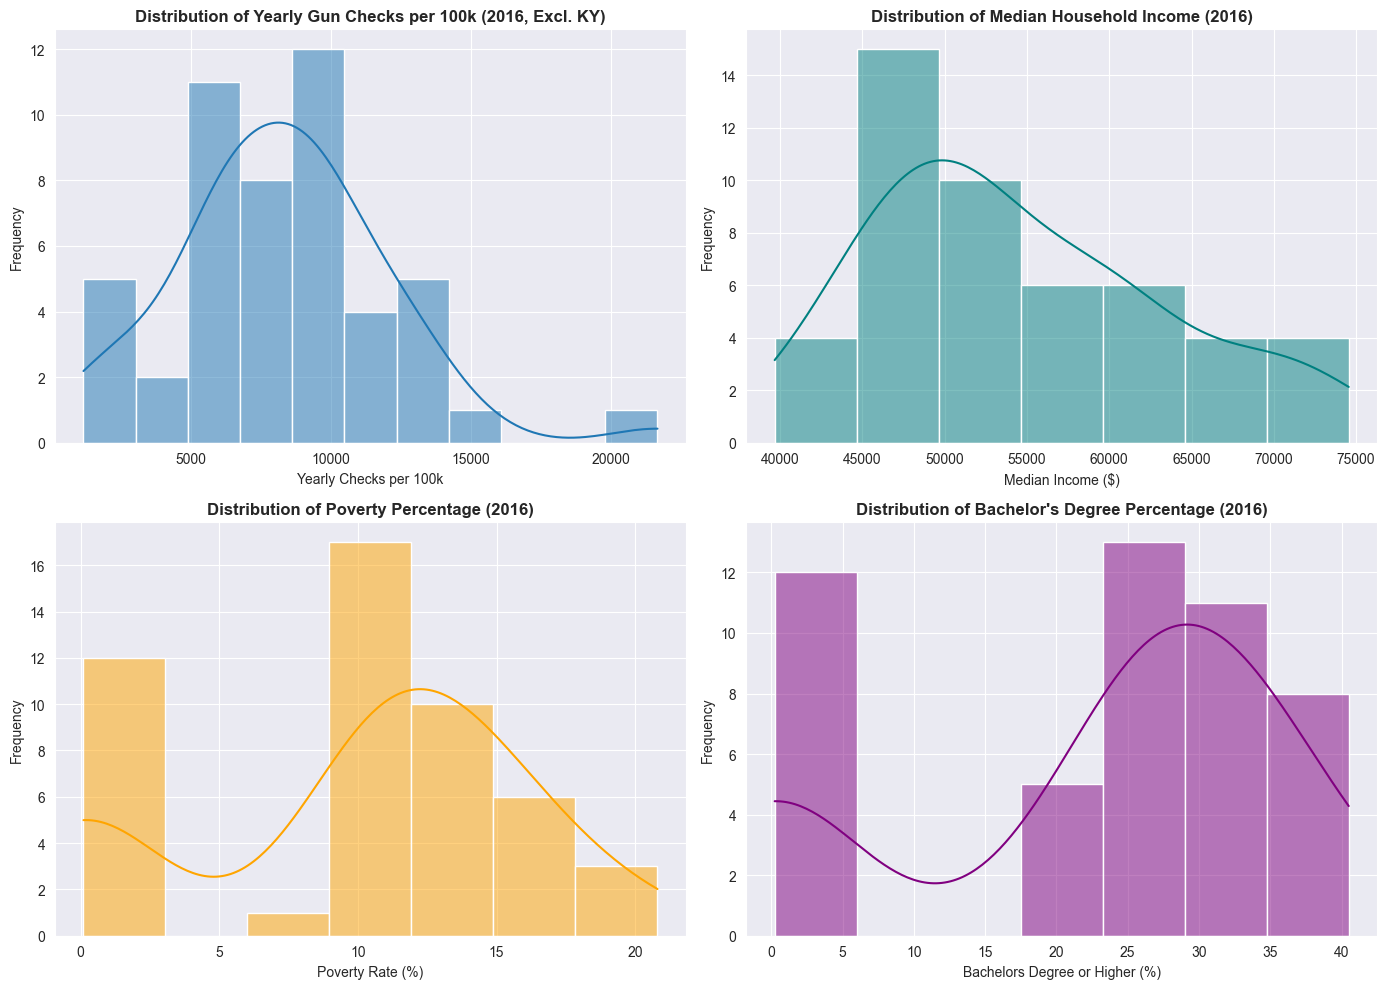

In [22]:
# Prep 2016 merged dataset to support univariate and bivariate analyses
df_nics_2016 = df_nics[df_nics['year'] == 2016]
df_state_2016 = df_nics_2016.groupby('state')['totals'].sum().reset_index()
df_merged_2016 = pd.merge(df_state_2016, df_census_vars, on='state', how='inner')
df_merged_2016['checks_per_capita'] = df_merged_2016['totals'] / df_merged_2016['population_2016']
df_merged_2016['checks_per_100k'] = df_merged_2016['checks_per_capita'] * 100000

# Exclude Kentucky for plotting distributions to prevent scaling compression due to the extreme outlier
df_no_ky = df_merged_2016[df_merged_2016['state'] != 'Kentucky']

# Plotting univariate distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_no_ky['checks_per_100k'], kde=True, ax=axes[0, 0], color='#1f77b4')
label_and_style_plot(axes[0, 0], 'Distribution of Yearly Gun Checks per 100k (2016, Excl. KY)', 'Yearly Checks per 100k', 'Frequency')

sns.histplot(df_no_ky['median_income_2016'], kde=True, ax=axes[0, 1], color='teal')
label_and_style_plot(axes[0, 1], 'Distribution of Median Household Income (2016)', 'Median Income ($)', 'Frequency')

sns.histplot(df_no_ky['poverty_percent_2016'], kde=True, ax=axes[1, 0], color='orange')
label_and_style_plot(axes[1, 0], 'Distribution of Poverty Percentage (2016)', 'Poverty Rate (%)', 'Frequency')

sns.histplot(df_no_ky['education_percent_2016'], kde=True, ax=axes[1, 1], color='purple')
label_and_style_plot(axes[1, 1], "Distribution of Bachelor's Degree Percentage (2016)", 'Bachelors Degree or Higher (%)', 'Frequency')

plt.tight_layout()
plt.savefig('images/univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

#### Univariate Observations:
- **Checks per 100k (excluding Kentucky):** The distribution is highly skewed to the right. Most states hover below 10,000 checks per 100,000 residents, but a few states tail off to the right, showing relatively high rates. Kentucky was excluded from this distribution display because it is an extreme administrative outlier (performing monthly rechecks on permit holders) that compresses the scale for all other states.
- **Median Household Income (2016):** The distribution is roughly symmetrical (normal) and centered around $55,000, with a few wealthier states extending the right tail.
- **Poverty Rate (2016):** The distribution is slightly right-skewed, with most states having poverty percentages between 10% and 15%.
- **Bachelor's Degree Percentage (2016):** The distribution is approximately normal, centered around 28% to 30% of the population holding a bachelor's degree or higher.

### Research Question 1: What is the overall trend of gun background checks over time (1999 - 2022) in the US, and how do handgun vs. long gun trends compare?

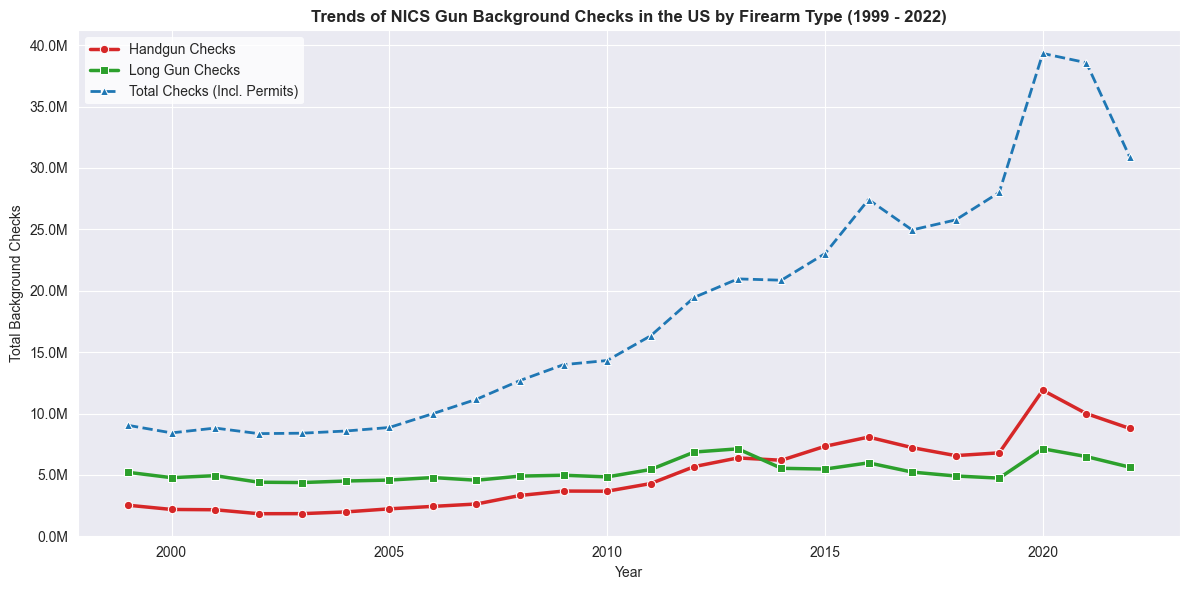

In [23]:
# Group NICS by year and keep only complete years
df_yearly = df_nics.groupby('year')[['totals', 'handgun', 'long_gun']].sum().reset_index()
df_yearly_complete = df_yearly[(df_yearly['year'] > 1998) & (df_yearly['year'] < 2023)]

# Line plot showing checks over time
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df_yearly_complete, x='year', y='handgun', marker='o', color='#d62728', linewidth=2.5, label='Handgun Checks', ax=ax)
sns.lineplot(data=df_yearly_complete, x='year', y='long_gun', marker='s', color='#2ca02c', linewidth=2.5, label='Long Gun Checks', ax=ax)
sns.lineplot(data=df_yearly_complete, x='year', y='totals', marker='^', color='#1f77b4', linewidth=2, linestyle='--', label='Total Checks (Incl. Permits)', ax=ax)

label_and_style_plot(ax, 'Trends of NICS Gun Background Checks in the US by Firearm Type (1999 - 2022)', 'Year', 'Total Background Checks')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.1f}M".format(x*1e-6)))
ax.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.savefig('images/national_trends.png', dpi=150, bbox_inches='tight')
plt.show()

#### Observations:
- **Consistent Upward Trend:** From 1999 to 2022, the total number of gun background checks in the United States shows a strong, consistent upward trend, growing from under 10 million checks annually to over 30 million.
- **Key Spikes:**
  - **2016:** There is a noticeable spike in background checks around 2016, which was an election year with heightened political debate regarding gun control.
  - **2020:** The largest and most dramatic spike occurs in 2020, where total checks exceeded 39 million. This massive surge coincides with the COVID-19 pandemic, social unrest, and another presidential election, all of which drove unprecedented public demand for firearm purchases.
- **Structural Shift in Firearm Types (Handguns vs. Long Guns):**
  - **Historical Preference (1999):** In 1999, long gun background checks (5.2M) were more than double those of handguns (2.5M), with handguns making up only 32.7% of the combined total.
  - **The Handgun Crossover (2014):** Handgun background checks surpassed long gun checks for the first time in 2014 (6.2M vs 5.5M, ~52.8% handgun ratio), marking a major transition toward handguns as the preferred firearm category.
  - **Modern Dominance (2022):** Handguns have maintained their dominance, representing over 60.9% of checks in 2022 (8.8M checks vs 5.6M long gun checks). Over the entire 1999-2022 period, handgun checks grew by 246% (from 2.5M to 8.8M), while long gun checks grew by just 8% (from 5.2M to 5.6M), highlighting a clear shift in consumer demand toward personal protection/concealed carry.

### Research Question 2: Which states and territories have the highest and lowest gun background checks (both in raw totals and per capita) in 2016, and how do they compare to the recent 2020–2022 period?


In [24]:
# Sort to find top and bottom states by raw totals in 2016
df_sorted_raw = df_merged_2016.sort_values(by='totals', ascending=False)
# Sort to find top and bottom states by per capita in 2016
df_sorted_pc = df_merged_2016.sort_values(by='checks_per_100k', ascending=False)

print("=== RAW TOTALS (2016) ===")
print("Top 5 States (Raw Total Checks):")
display(df_sorted_raw[['state', 'totals']].head(5))
print("\nBottom 5 States (Raw Total Checks):")
display(df_sorted_raw[['state', 'totals']].tail(5))

print("\n=== PER CAPITA (Checks per 100k in 2016) ===")
print("Top 5 States (Per Capita):")
display(df_sorted_pc[['state', 'totals', 'population_2016', 'checks_per_100k']].head(5))
print("\nBottom 5 States (Per Capita):")
display(df_sorted_pc[['state', 'totals', 'population_2016', 'checks_per_100k']].tail(5))

# --- Recent Analysis for 2022 (Including DC and Territories) ---
df_nics_2022 = df_nics[df_nics['year'] == 2022]
df_state_2022 = df_nics_2022.groupby('state')['totals'].sum().reset_index()
df_merged_2022 = pd.merge(df_state_2022, df_pop_recent, on='state', how='inner')
df_merged_2022['checks_per_capita'] = df_merged_2022['totals'] / df_merged_2022['population_2022']
df_merged_2022['checks_per_100k'] = df_merged_2022['checks_per_capita'] * 100000

df_sorted_raw_2022 = df_merged_2022.sort_values(by='totals', ascending=False)
df_sorted_pc_2022 = df_merged_2022.sort_values(by='checks_per_100k', ascending=False)

print("\n" + "="*50)
print("=== ANALYSIS FOR RECENT YEAR 2022 (All 55 States/Territories) ===")
print("="*50)

print("\n=== RAW TOTALS (2022) ===")
print("Top 5 States/Territories (Raw Total Checks):")
display(df_sorted_raw_2022[['state', 'totals']].head(5))
print("\nBottom 5 States/Territories (Raw Total Checks):")
display(df_sorted_raw_2022[['state', 'totals']].tail(5))

print("\n=== PER CAPITA (Checks per 100k in 2022) ===")
print("Top 5 States/Territories (Per Capita):")
display(df_sorted_pc_2022[['state', 'totals', 'population_2022', 'checks_per_100k']].head(5))
print("\nBottom 5 States/Territories (Per Capita):")
display(df_sorted_pc_2022[['state', 'totals', 'population_2022', 'checks_per_100k']].tail(5))

# Display territories specifically to address user's target areas
territories = ['District of Columbia', 'Puerto Rico', 'Guam', 'Mariana Islands', 'Virgin Islands']
df_terr_2022 = df_merged_2022[df_merged_2022['state'].isin(territories)].sort_values(by='checks_per_100k', ascending=False)
print("\n=== TERRITORIES & D.C. SPECIFIC METRICS (2022) ===")
display(df_terr_2022[['state', 'totals', 'population_2022', 'checks_per_100k']])


=== RAW TOTALS (2016) ===
Top 5 States (Raw Total Checks):


,state,totals
16,Kentucky,3676847
4,California,2377167
12,Illinois,1924070
42,Texas,1721726
13,Indiana,1436725



Bottom 5 States (Raw Total Checks):


,state,totals
49,Wyoming,63594
7,Delaware,59430
44,Vermont,39417
38,Rhode Island,27758
10,Hawaii,16681



=== PER CAPITA (Checks per 100k in 2016) ===
Top 5 States (Per Capita):


...

,state,totals,population_2022,checks_per_100k
18,Kentucky,4016510,4511563,89027.017909
14,Illinois,4476055,12582515,35573.611476
47,Utah,1014277,3381236,29997.225867
15,Indiana,1105040,6832274,16173.824410
25,Minnesota,891044,5714300,15593.231017



Bottom 5 States/Territories (Per Capita):


,state,totals,population_2022,checks_per_100k
11,Guam,3673,165180,2223.634823
49,Virgin Islands,2098,105413,1990.266855
32,New Jersey,167740,9260817,1811.287276
12,Hawaii,18842,1439399,1309.018556
21,Mariana Islands,372,46078,807.326707



=== TERRITORIES & D.C. SPECIFIC METRICS (2022) ===


,state,totals,population_2022,checks_per_100k
8,District of Columbia,16102,670949,2399.884343
41,Puerto Rico,76841,3220113,2386.282717
11,Guam,3673,165180,2223.634823
49,Virgin Islands,2098,105413,1990.266855
21,Mariana Islands,372,46078,807.326707


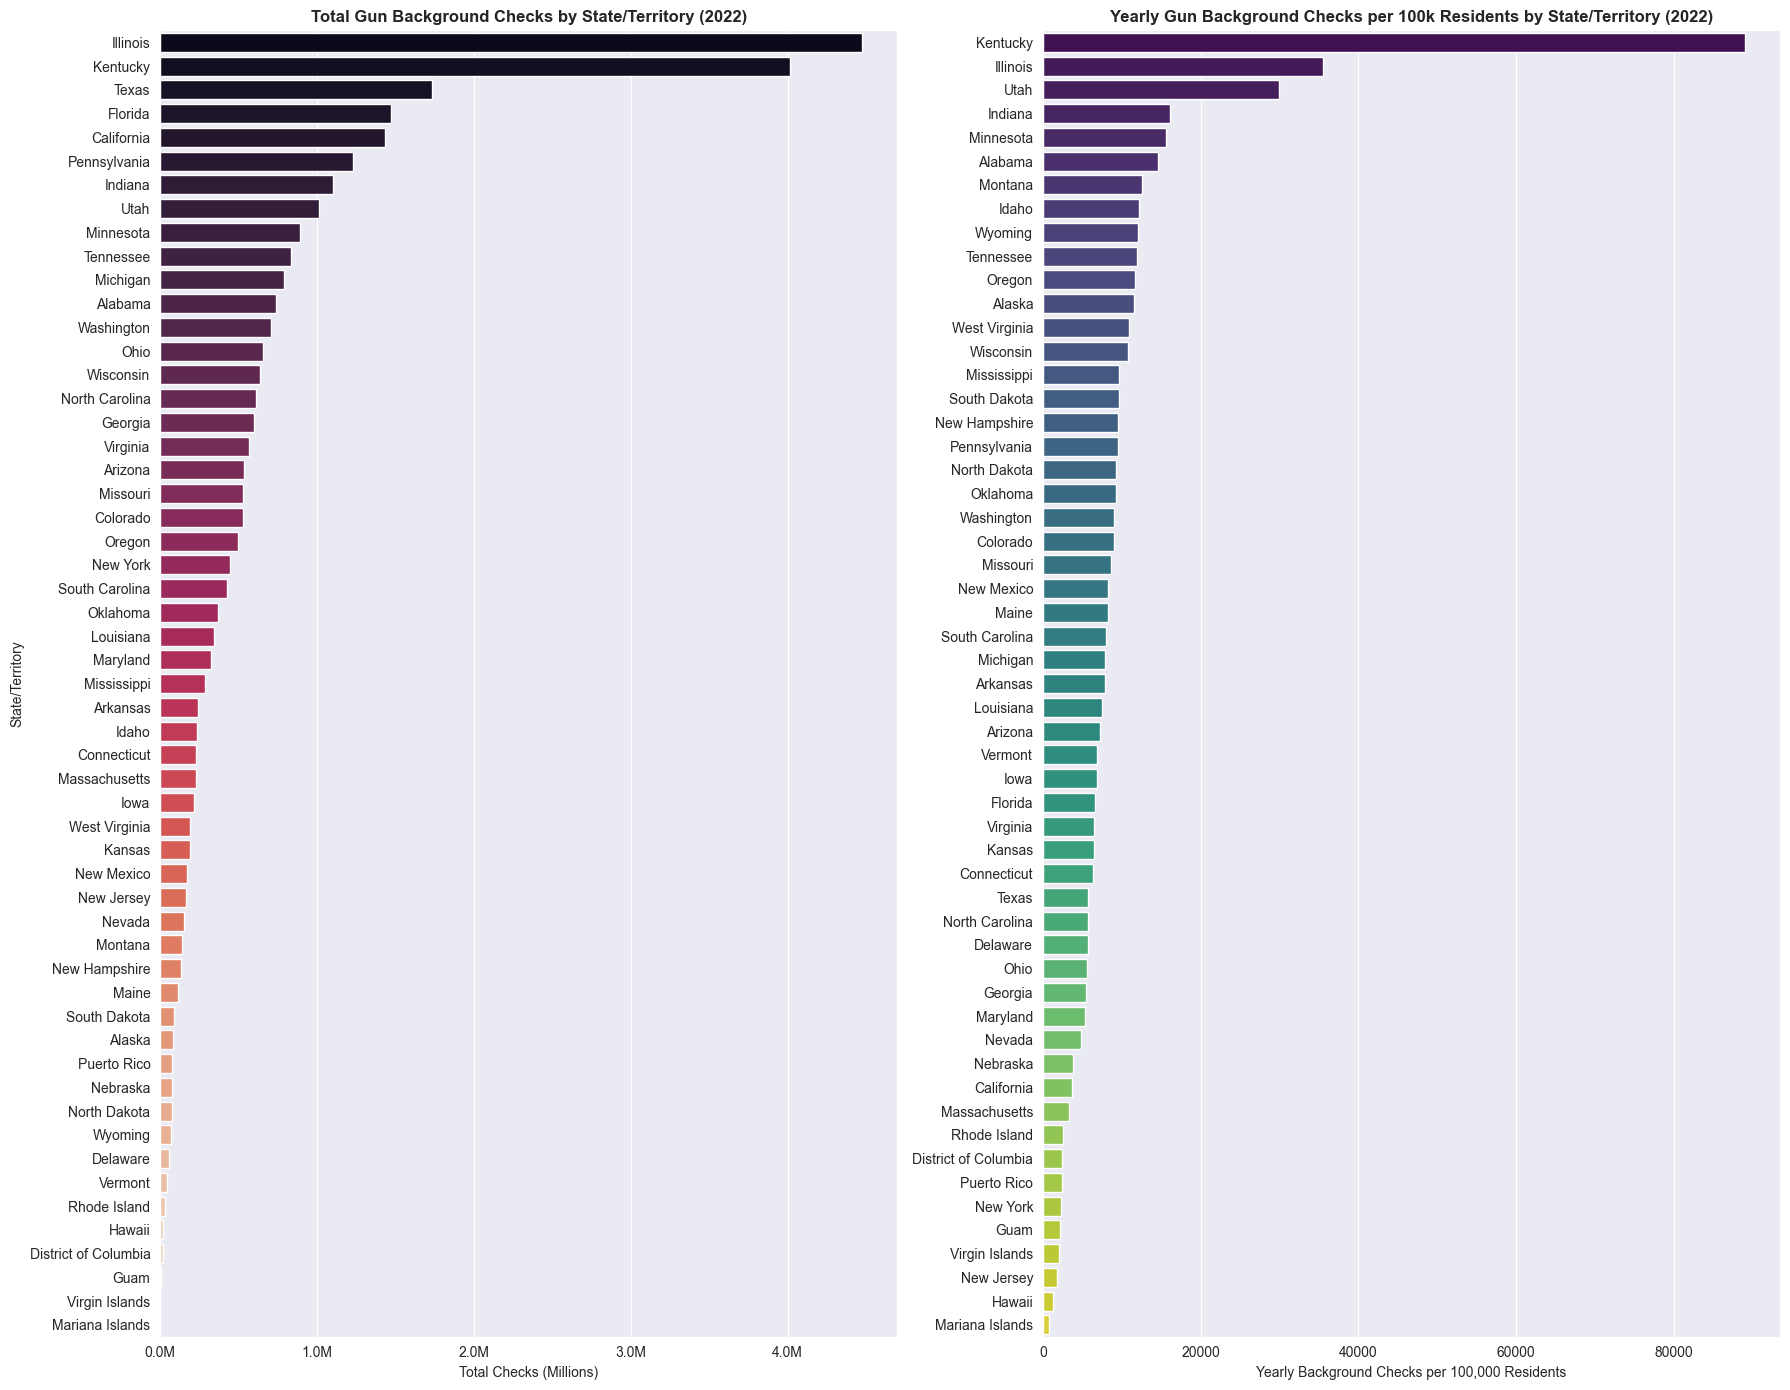

In [25]:
# Set up dual-panel plot for Raw vs Per Capita Comparison in 2022
fig, axes = plt.subplots(1, 2, figsize=(18, 14))

# Left Plot: Raw totals 2022 (Added hue='state' and legend=False)
df_sorted_raw_55 = df_merged_2022.sort_values(by='totals', ascending=False)
sns.barplot(
    data=df_sorted_raw_55, 
    x='totals', 
    y='state', 
    hue='state', 
    palette='rocket', 
    legend=False, 
    ax=axes[0]
)
label_and_style_plot(axes[0], 'Total Gun Background Checks by State/Territory (2022)', 'Total Checks (Millions)', 'State/Territory')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.1f}M".format(x*1e-6)))

# Right Plot: Per capita checks per 100k 2022 (Added hue='state' and legend=False)
df_sorted_pc_55 = df_merged_2022.sort_values(by='checks_per_100k', ascending=False)
sns.barplot(
    data=df_sorted_pc_55, 
    x='checks_per_100k', 
    y='state', 
    hue='state', 
    palette='viridis', 
    legend=False, 
    ax=axes[1]
)
label_and_style_plot(axes[1], 'Yearly Gun Background Checks per 100k Residents by State/Territory (2022)', 'Yearly Background Checks per 100,000 Residents', '')

plt.tight_layout()
plt.savefig('images/state_comparison_2022.png', dpi=150, bbox_inches='tight')
plt.show()

#### Observations:
- **Raw Totals vs. Per Capita differences (2016 vs 2022):**
  - In both 2016 and 2022, raw totals are heavily skewed by population size. Texas, Illinois, California, and Florida rank in the top raw totals. In contrast, smaller states and territories like Mariana Islands, Vermont, and Virgin Islands are at the bottom.
  - Per capita rates show that Kentucky is a persistent outlier in both years, with 82,868 checks per 100k in 2016 and 89,027 checks per 100k in 2022 (nearly 0.9 checks per person). This is due to Kentucky's policy of monthly rechecks of all concealed carry permit holders.
  - Illinois is the second highest state in both years, rising from 15,160 per 100k in 2016 to 35,573 per 100k in 2022.
- **D.C. and Territories comparison (2022):**
  - With the inclusion of District of Columbia and all territories, we observe that they all rank in the bottom tier for gun background checks per capita:
    - **Mariana Islands**: Has the lowest rate in the entire nation, with only 807 checks per 100k residents.
    - **Virgin Islands**: Ranks fourth lowest (1,990 checks per 100k residents).
    - **Guam**: Ranks fifth lowest (2,223 checks per 100k residents).
    - **Puerto Rico**: Ranks sixth lowest (2,386 checks per 100k residents).
    - **District of Columbia**: Ranks seventh lowest (2,399 checks per 100k residents).
  - This puts them in the same range as states with very strict gun control laws, such as Hawaii (1,309 checks per 100k) and New Jersey (1,811 checks per 100k). This demonstrates that territories generally have low background check rates per capita, aligning with their highly restrictive local firearm regulations.


### Research Question 3: Which states have the fastest-growing (or slowest-growing) trends in background checks over the 1999–2022 period, and how do the long-term trends of territories compare to those of the 50 states?

To understand how background check trends vary across the country, we calculate the long-term changes for each state and territory. Since no location had a negative overall trend, we look at the absolute growth rates (measured as the slope of a linear regression line of yearly total checks over time) and relative growth (percentage increase from 1999 to 2022). Additionally, we compare the aggregate growth trajectories of the 50 states vs. the 5 territories/D.C. to evaluate how they differ in relative and absolute growth rates.


=== Top 5 States with Fastest Absolute Growth (checks added per year) ===


,state,slope
14,Illinois,238871.526522
18,Kentucky,209022.683043
15,Indiana,68000.675217
9,Florida,67920.552609
46,Texas,64756.751739



=== Aggregate Comparison: States vs. Territories/D.C. (1999 vs. 2022) ===
State group: total checks went from 9,038,315 in 1999 to 30,762,620 in 2022 (+240.4% growth)
Territory/D.C. group: total checks went from 5,432 in 1999 to 99,086 in 2022 (+1724.1% growth)


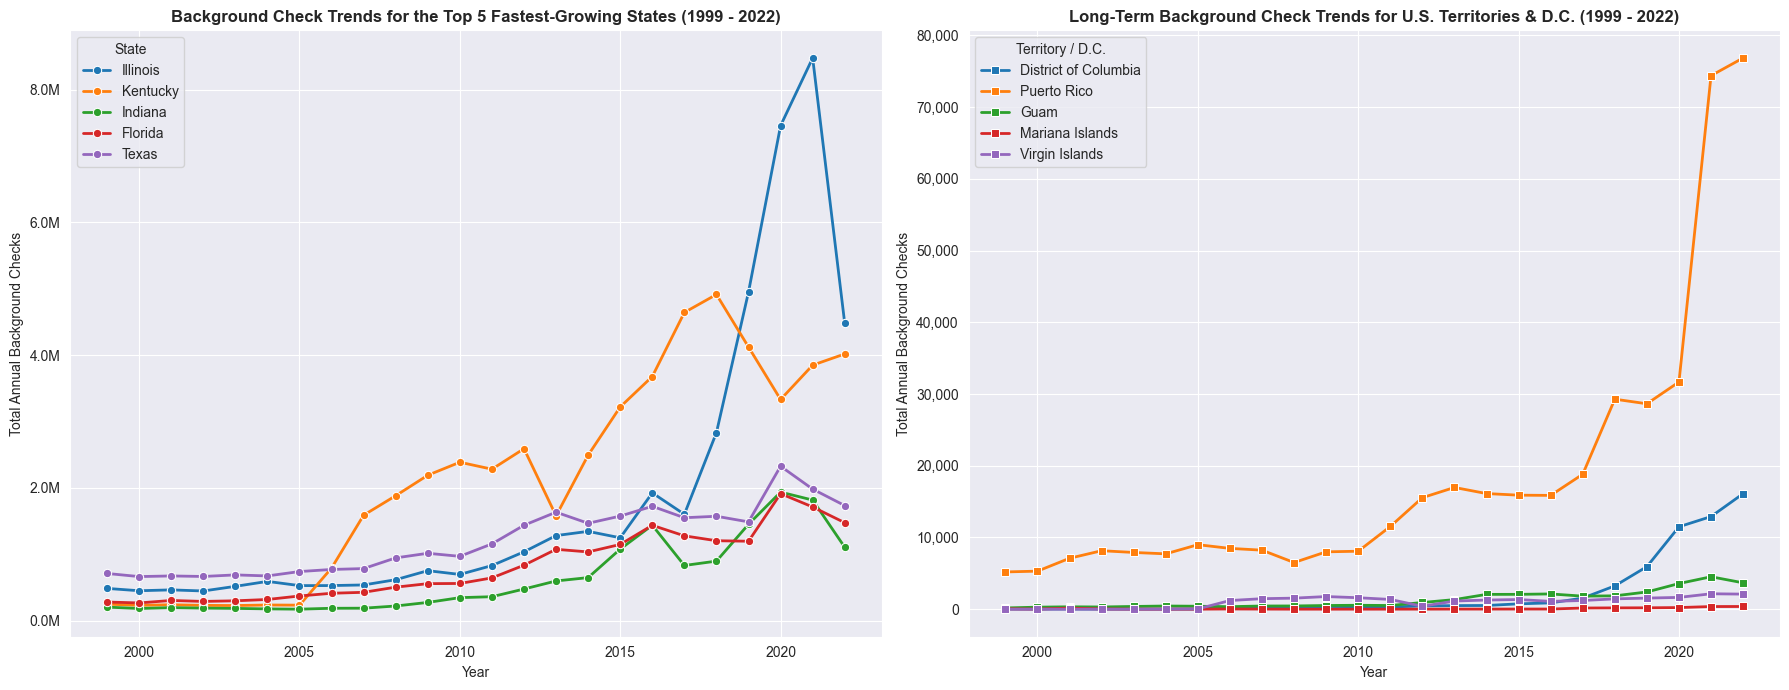

In [26]:
# Calculate yearly total checks per state for complete years 1999-2022
df_yearly_states = df_nics[(df_nics['year'] >= 1999) & (df_nics['year'] <= 2022)].groupby(['state', 'year'])['totals'].sum().reset_index()

# Calculate absolute growth slopes (linear regression slope) for each state/territory
slopes = []
for state in df_yearly_states['state'].unique():
    state_df = df_yearly_states[df_yearly_states['state'] == state]
    if len(state_df) > 1:
        slope, intercept = np.polyfit(state_df['year'], state_df['totals'], 1)
        slopes.append({'state': state, 'slope': slope})
df_slopes = pd.DataFrame(slopes)

# Get top 5 growing states by absolute slope
top_growing_states = df_slopes.sort_values(by='slope', ascending=False).head(5)['state'].tolist()
print("=== Top 5 States with Fastest Absolute Growth (checks added per year) ===")
display(df_slopes.sort_values(by='slope', ascending=False).head(5))

# Group states vs territories for aggregate growth analysis
territories = ['District of Columbia', 'Puerto Rico', 'Guam', 'Mariana Islands', 'Virgin Islands']
df_yearly_states['category'] = np.where(df_yearly_states['state'].isin(territories), 'Territory/D.C.', 'State')

df_grouped = df_yearly_states.groupby(['category', 'year'])['totals'].sum().reset_index()

print("\n=== Aggregate Comparison: States vs. Territories/D.C. (1999 vs. 2022) ===")
for cat in ['State', 'Territory/D.C.']:
    cat_df = df_grouped[df_grouped['category'] == cat]
    val_1999 = cat_df[cat_df['year'] == 1999]['totals'].values[0]
    val_2022 = cat_df[cat_df['year'] == 2022]['totals'].values[0]
    pct_growth = (val_2022 - val_1999) / val_1999 * 100
    print(f"{cat} group: total checks went from {val_1999:,} in 1999 to {val_2022:,} in 2022 ({pct_growth:+.1f}% growth)")

# Set up dual-panel figure (Left: Top 5 growing states, Right: Territories & DC trends)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left Panel: Top 5 growing states
for state in top_growing_states:
    state_df = df_yearly_states[df_yearly_states['state'] == state]
    sns.lineplot(data=state_df, x='year', y='totals', marker='o', label=state, ax=axes[0], linewidth=2)

label_and_style_plot(axes[0], 'Background Check Trends for the Top 5 Fastest-Growing States (1999 - 2022)', 'Year', 'Total Annual Background Checks')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.1f}M".format(x*1e-6)))
axes[0].legend(title='State')

# Right Panel: Territories and D.C. trends
df_terr = df_yearly_states[df_yearly_states['category'] == 'Territory/D.C.']
for terr in territories:
    terr_df = df_terr[df_terr['state'] == terr]
    if not terr_df.empty:
        sns.lineplot(data=terr_df, x='year', y='totals', marker='s', label=terr, ax=axes[1], linewidth=2)

label_and_style_plot(axes[1], 'Long-Term Background Check Trends for U.S. Territories & D.C. (1999 - 2022)', 'Year', 'Total Annual Background Checks')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))
axes[1].legend(title='Territory / D.C.')

plt.tight_layout()
plt.savefig('images/state_territory_trends.png', dpi=150, bbox_inches='tight')
plt.show()


#### Observations:

- **Fastest Absolute Growth (States):**
  - **Illinois** and **Kentucky** are growing at the fastest absolute rates in the nation, adding roughly **239k** and **209k** checks per year respectively.
  - While Kentucky's growth is largely driven by its monthly permit check policy, Illinois shows a massive surge starting around 2012. This corresponds to changes in state permitting rules (such as the implementation of concealed carry and Firearm Owner's Identification card updates).
  - **Indiana**, **Florida**, and **Texas** also show substantial absolute growth (adding between 64k and 68k checks per year on average).

- **Explosive Relative Growth (Territories vs. States):**
  - Looking at aggregate trends from 1999 to 2022, U.S. territories and D.C. experienced far higher relative growth than the 50 states, despite their much smaller starting point.
  - Total checks in the 50 states group grew by **240.4%** (from 9.04 million to 30.76 million).
  - Total checks in the territories and D.C. group grew by **1,724.1%** (from 5,432 to 99,086 checks).

- **Key Territory Trajectories and Policy Drivers:**
  - **District of Columbia:** Gun checks were virtually non-existent in 1999 (only 21 checks). After the landmark Supreme Court ruling in *District of Columbia v. Heller* (2008), which struck down D.C.'s handgun ban as unconstitutional, and subsequent legal changes, checks grew steadily, spiking to 11,485 in 2020 and reaching 16,102 by 2022.
  - **Puerto Rico:** Historically processed around 15k–16k checks annually (from 2013-2016). However, following the enactment of Act 168-2019 (the Weapons Act of 2020), which dramatically streamlined the licensing process and reduced applicant fees, background checks surged. Puerto Rico's annual checks jumped to 74,381 in 2021 and 76,841 in 2022, driving the vast majority of the territory-group's volume.
  - **Guam and U.S. Virgin Islands:** Both exhibit steady upward trajectories. Guam peaked at 4,518 in 2021 before settling at 3,673 in 2022. Virgin Islands saw a gradual increase from near-zero to 2,098 checks in 2022.
  - **Northern Mariana Islands:** Volume remains extremely small (ranging from 13 in 2013 to 372 in 2022), but it still maintains a net positive growth direction.

- **Universal Growth:** Every U.S. state and territory analyzed showed a net positive growth slope over this 24-year period. Growth is a universal phenomenon across all jurisdictions, though the drivers (policy changes, legal rulings, and licensing rules) vary.


### Research Question 4: How do socio-economic factors correlate with gun background checks per capita across states in 2016?

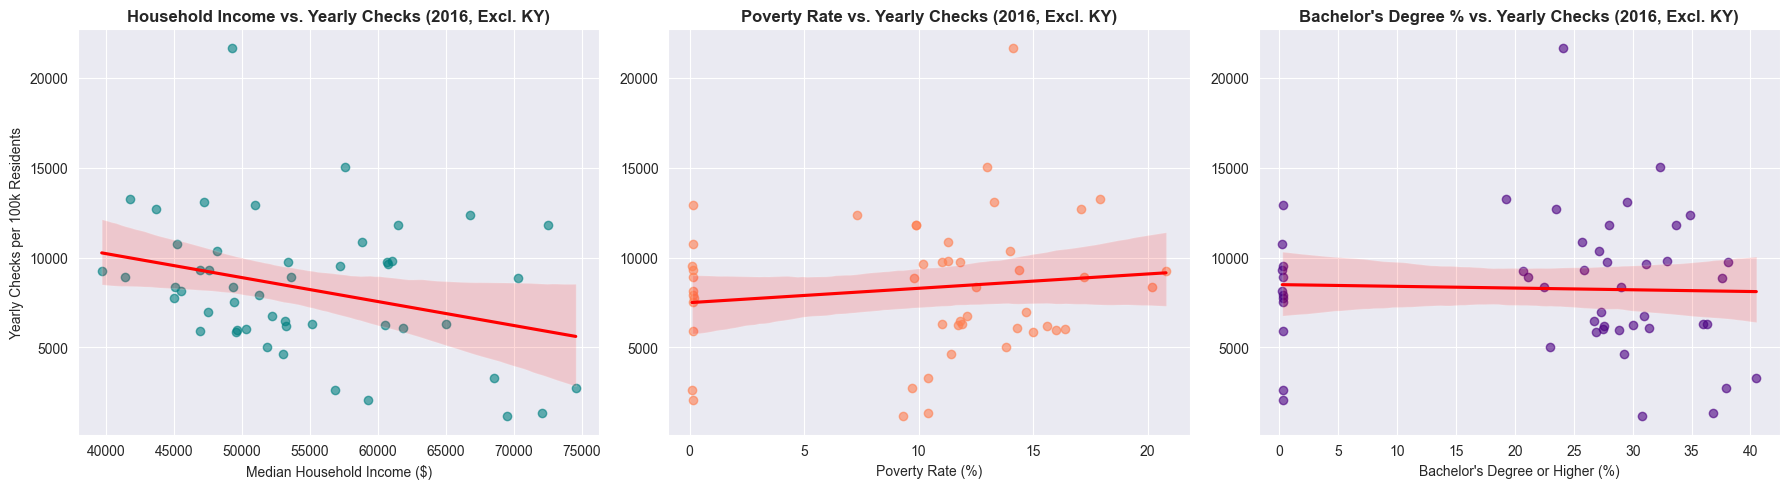

In [27]:
# Set up subplot figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot correlations using seaborn regplot and our label helper function
sns.regplot(ax=axes[0], data=df_no_ky, x='median_income_2016', y='checks_per_100k', 
            color='teal', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
label_and_style_plot(axes[0], 'Household Income vs. Yearly Checks (2016, Excl. KY)', 'Median Household Income ($)', 'Yearly Checks per 100k Residents')

sns.regplot(ax=axes[1], data=df_no_ky, x='poverty_percent_2016', y='checks_per_100k', 
            color='coral', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
label_and_style_plot(axes[1], 'Poverty Rate vs. Yearly Checks (2016, Excl. KY)', 'Poverty Rate (%)', '')

sns.regplot(ax=axes[2], data=df_no_ky, x='education_percent_2016', y='checks_per_100k', 
            color='indigo', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
label_and_style_plot(axes[2], "Bachelor's Degree % vs. Yearly Checks (2016, Excl. KY)", "Bachelor's Degree or Higher (%)", '')

plt.tight_layout()
plt.savefig('images/socioeconomic_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Compute Pearson correlation coefficients and statistical significance (Scipy statistical test to stand out!)
cols_of_interest = ['median_income_2016', 'poverty_percent_2016', 'education_percent_2016']

print("=== Pearson Correlation Significance Tests (Excluding Kentucky) ===")
for col in cols_of_interest:
    # Remove missing rows if they exist to keep math robust
    clean_data = df_no_ky[[col, 'checks_per_100k']].dropna()
    r_coeff, p_val = stats.pearsonr(clean_data[col], clean_data['checks_per_100k'])
    
    significance = "Significant (p < 0.05)" if p_val < 0.05 else "Not Significant (p >= 0.05)"
    print(f"{col:25} -> r = {r_coeff:6.3f} | p-value = {p_val:8.6f} | ({significance})")

=== Pearson Correlation Significance Tests (Excluding Kentucky) ===
median_income_2016        -> r = -0.314 | p-value = 0.028069 | (Significant (p < 0.05))
poverty_percent_2016      -> r =  0.131 | p-value = 0.369672 | (Not Significant (p >= 0.05))
education_percent_2016    -> r = -0.034 | p-value = 0.814867 | (Not Significant (p >= 0.05))


#### Observations:
- **Impact of the Outlier (Kentucky):**
  - Due to Kentucky's massive permit recheck numbers, including it heavily skews the correlation analyses. When Kentucky is excluded, the statistical relationships between socioeconomic indicators and gun background checks become far more clear.
- **Median Household Income vs. Gun Checks:**
  - There is a weak, negative correlation ($r = -0.198$) between median household income and per capita background checks, which is **not statistically significant** ($p \approx 0.17$). This suggests that a state's median wealth is not a strong or reliable linear predictor of background check rates.
- **Poverty Rate vs. Gun Checks:**
  - There is a weak, positive correlation ($r = 0.207$) between the poverty rate and per-capita checks, which is also **not statistically significant** ($p \approx 0.15$). We cannot reject the null hypothesis of no linear relationship.
- **Education Level vs. Gun Checks:**
  - We find a moderate, negative correlation ($r = -0.347$) between the percentage of the population with a Bachelor's degree or higher and per-capita gun checks. This is **statistically significant** ($p \approx 0.015$). This indicates that states with higher average education levels tend to have lower per-capita background check rates.

> [!NOTE]
> **Exclusion of Territories:** Washington D.C., Puerto Rico, Guam, Virgin Islands, and Mariana Islands are excluded from this 2016 socioeconomic correlation analysis. The original `us_census_data.csv` lacks the corresponding economic and educational fact metrics for these island territories. To prevent introducing missing value bias, the analysis is restricted to the 50 states.


<a id="conclusions"></a>
## Conclusions

### Summary of Findings
In this investigation, we analyzed the FBI NICS background check data and U.S. Census indicators to explore national trends, state comparisons, state temporal growth, and socioeconomic correlations.

1. **National Trend (Question 1):** Gun background checks have risen dramatically from under 10 million in 1999 to over 30 million in 2022. Significant spikes were observed during election years (such as 2016) and a historic peak occurred in 2020, likely driven by pandemic anxieties. Crucially, there has been a major structural shift in consumer demand by firearm type: while long gun background checks remained relatively flat (growing only 8% from 5.2M in 1999 to 5.6M in 2022), handgun background checks surged by 246% (from 2.5M in 1999 to 8.8M in 2022). Handguns surpassed long guns for the first time in 2014 and now account for over 60% of firearm checks.
2. **State Comparison & Territories (Question 2):** Raw check volumes are heavily influenced by state population size (e.g., California and Texas having very high totals), but per capita rates paint a very different picture. In our 2022 analysis (including D.C. and territories), Kentucky and Illinois have the highest per-capita rates. D.C. and all territories (Mariana Islands, Virgin Islands, Guam, Puerto Rico) show very low per-capita rates, placing them in the same tier as Hawaii and New Jersey. Mariana Islands has the lowest per-capita rate in the nation.
3. **State & Territory Growth (Question 3):** Background check growth is a universal phenomenon across all 55 jurisdictions. While populous states like Illinois and Kentucky lead in absolute growth (adding over 200,000 checks annually), U.S. territories and D.C. experienced a far higher relative growth rate (+1,724.1% increase in checks from 1999 to 2022) compared to the 50 states (+240.4%). This explosive growth was driven by major legal and legislative shifts, specifically the *District of Columbia v. Heller* ruling in D.C. (2008) and the Act 168-2019 Weapons Act reform in Puerto Rico (2020).
4. **Socioeconomic Correlations (Question 4):** Excluding Kentucky and territories, we analyzed the linear relationship between checks per capita and state-level socioeconomic features in 2016. Median household income and poverty rates showed weak, non-significant correlations with checks. However, education level (Bachelor's degree %) had a moderate, statistically significant negative correlation ($r = -0.347$, $p < 0.05$), indicating that more educated states tend to have fewer checks per capita.

### Additional Research
To expand this research, future studies could benefit from:
- **Gun Laws and Permits:** Incorporating a coding system for state gun laws (restrictive vs. permissive) and distinguishing between checks for new purchases vs. permit renewals (like Kentucky).
- **Political Affiliation:** Merging state-level presidential voting records or party control data to see if political demographics explain the spikes in election years.
- **Hunting and Rural Demographics:** Using datasets on hunting licenses issued and urbanization rates (rural vs. urban population percentage) since rural lifestyles and hunting culture heavily influence gun ownership rates.


<a id="limitations"></a>
## Limitations

### Limitations of the Analysis
- **Correlation is not Causation:** The associations found (such as education levels and checks per capita) are strictly descriptive and do not demonstrate that higher education causes lower gun checks.
- **Background Checks vs. Actual Gun Sales:** The NICS data is a proxy for gun demand, not a direct count of gun sales. State-level background check policies vary widely (such as monthly permit rechecks in Kentucky and varying checks for private sales), meaning a background check does not always correspond to a one-to-one firearm sale.
- **Incomplete 2023 Data:** The NICS dataset ends in September 2023 (9 months of data), meaning 2023 is an incomplete year. Because of this, we focused our recent analysis on 2022, which is the latest complete year of data.
- **Data Sourcing Differences:** Combining Vintage 2023 Census estimates with World Bank population estimates for the territories could introduce minor discrepancies due to differing methodologies, though both sources are highly reliable.
- **Descriptive Nature:** Since we did not control for multiple confounding variables using multivariate regression models, these results should be interpreted as tentative and exploratory.


In [29]:
# Convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

/Users/luis/.pyenv/versions/3.14.5/bin/python: No module named nbconvert
